### Snow Model Forcing
#### `3_read_wind_ninja_output.ipynb` 
#### This turned into me trying to read the `kmz` files in python since I did not know you could output ascii files in Wind Ninja
Now, I have a new script `_ascii` for output with the updated config file... leaving this one here for now if I want to work with the kmz here in the future?? prob not...


created by Cassie Lumbrazo\
last updated: Oct 2025\
run location: UAS linux\
python environment: **rasterio**

In [1]:
# import packages 
%matplotlib inline

# plotting packages 
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns 

sns.set_theme()
# plt.rcParams['figure.figsize'] = [12,6] #overriding size

# data packages 
import pandas as pd
import numpy as np
import xarray as xr
from datetime import datetime

import scipy

from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap
from matplotlib import ticker

##### Approach 1: Extract and parse .kmz → .kml → GeoTIFF

Here’s a straightforward way to load the .kmz output into Python and convert it into a raster array you can use like a NetCDF:

In [5]:
import zipfile
import os
import rasterio
import xarray as xr
import numpy as np

def kmz_to_xarray(kmz_path):
    # 1. Unzip the KMZ
    extract_dir = kmz_path.replace('.kmz', '_unzipped')
    os.makedirs(extract_dir, exist_ok=True)
    with zipfile.ZipFile(kmz_path, 'r') as kmz:
        kmz.extractall(extract_dir)

    # 2. Find any raster file (often PNG + .pgw world file)
    rasters = [f for f in os.listdir(extract_dir) if f.endswith(('.tif', '.png'))]
    if not rasters:
        raise FileNotFoundError("No raster files found inside KMZ")

    raster_path = os.path.join(extract_dir, rasters[0])

    # 3. Try to read it as a georeferenced image
    with rasterio.open(raster_path) as src:
        data = src.read(1)
        transform = src.transform
        crs = src.crs

        da = xr.DataArray(
            data,
            dims=("y", "x"),
            coords={
                "x": np.arange(data.shape[1]) * transform.a + transform.c,
                "y": np.arange(data.shape[0]) * transform.e + transform.f,
            },
            attrs={
                "crs": str(crs),
                "transform": transform,
                "description": "WindNinja output from KMZ"
            }
        )
    return da


Then run this, 

In [8]:
da = kmz_to_xarray("/hdd/snow_hydrology/wind_ninja/test4/output/windninja_20241001_0700/dem_10m_UTM_clip_powderpatch_filled_gdal_100m.kmz")
da.plot()

FileNotFoundError: No raster files found inside KMZ

#### Approach 2: Convert all KMZ files → NetCDF

If you have many .kmz files (e.g., one per timestep), batch-convert them into one combined NetCDF:

In [9]:
import glob

kmz_files = sorted(glob.glob("/hdd/snow_hydrology/wind_ninja/test4/output/**/*.kmz", recursive=True))

data_arrays = []
times = []

for f in kmz_files:
    da = kmz_to_xarray(f)
    # Extract timestamp from filename, e.g. windninja_YYYYMMDD_HHMM.kmz
    ts = f.split("_")[-1].replace(".kmz", "")
    times.append(np.datetime64(ts, "m"))
    data_arrays.append(da)

ds = xr.concat(data_arrays, dim="time")
ds = ds.assign_coords(time=("time", times))
ds.to_netcdf("/hdd/snow_hydrology/wind_ninja/test4/windninja_outputs.nc")

FileNotFoundError: No raster files found inside KMZ

Trying something else... since none of that is working right now 

In [10]:
import zipfile
import os
import glob
import numpy as np
import xarray as xr
import rasterio
from rasterio.transform import from_origin
from PIL import Image

In [15]:
def extract_kmz_raster(kmz_path):
    """Extracts the main raster from a WindNinja KMZ file (e.g. PNG + PGW)"""
    extract_dir = kmz_path.replace('.kmz', '_unzipped')
    os.makedirs(extract_dir, exist_ok=True)

    # Extract all files
    with zipfile.ZipFile(kmz_path, 'r') as kmz:
        kmz.extractall(extract_dir)

    # Find possible raster image (png or jpg)
    image_files = []
    for root, _, files in os.walk(extract_dir):
        for f in files:
            if f.lower().endswith(('.png', '.jpg', '.jpeg')):
                image_files.append(os.path.join(root, f))

    if not image_files:
        raise FileNotFoundError(f"No raster image found in {kmz_path}")

    # Use the first image (WindNinja usually only makes one per KMZ)
    image_path = image_files[0]
    worldfile_path = os.path.splitext(image_path)[0] + '.pgw'

    # Read the image as grayscale or RGB
    img = np.array(Image.open(image_path))
    if img.ndim == 3:  # Convert RGB to grayscale if needed
        img = img.mean(axis=2)

    # Parse worldfile (.pgw) for georeferencing
    if not os.path.exists(worldfile_path):
        raise FileNotFoundError(f"Missing worldfile (.pgw) for {image_path}")

    with open(worldfile_path, 'r') as wf:
        A = float(wf.readline())  # pixel size in x
        D = float(wf.readline())  # rotation term (usually 0)
        B = float(wf.readline())  # rotation term (usually 0)
        E = float(wf.readline())  # pixel size in y (negative)
        C = float(wf.readline())  # x coordinate of upper left pixel center
        F = float(wf.readline())  # y coordinate of upper left pixel center

    transform = from_origin(C, F, A, abs(E))
    crs = "EPSG:32608"  # WGS84 / UTM zone 8N for Juneau region

    # Convert to xarray DataArray
    da = xr.DataArray(
        img,
        dims=("y", "x"),
        coords={
            "x": np.arange(img.shape[1]) * A + C,
            "y": np.arange(img.shape[0]) * E + F,
        },
        attrs={
            "transform": transform,
            "crs": crs,
            "description": f"Extracted from {os.path.basename(kmz_path)}"
        }
    )

    return da

def load_all_windninja_kmz(output_dir):
    """Finds and loads all WindNinja KMZ outputs into a single dataset"""
    kmz_files = sorted(glob.glob(os.path.join(output_dir, "**/*.kmz"), recursive=True))
    if not kmz_files:
        raise FileNotFoundError(f"No KMZ files found under {output_dir}")

    data_arrays = []
    times = []

    for f in kmz_files:
        print(f"Processing {f}")
        da = extract_kmz_raster(f)
        # Try to extract timestamp from folder name like windninja_YYYYMMDD_HHMM
        parent = os.path.basename(os.path.dirname(f))
        try:
            ts_str = parent.replace("windninja_", "")
            ts = np.datetime64(ts_str, "m")
        except Exception:
            ts = np.datetime64("NaT")
        data_arrays.append(da)
        times.append(ts)

    ds = xr.concat(data_arrays, dim="time")
    ds = ds.assign_coords(time=("time", times))
    return ds

It automatically walks through all subfolders under your output directory.

It handles .png + .pgw raster pairs inside .kmz.

It assumes UTM Zone 8N (EPSG:32608) — you can change crs if needed.

The dataset will have dimensions (time, y, x) and coordinate labels from the worldfile.

And use those,

In [16]:
output_dir = "/hdd/snow_hydrology/wind_ninja/test4/output"
ds = load_all_windninja_kmz(output_dir)
print(ds)
ds.to_netcdf("/hdd/snow_hydrology/wind_ninja/test4/windninja_outputs.nc")

Processing /hdd/snow_hydrology/wind_ninja/test4/output/windninja_20241001_0500/dem_10m_UTM_clip_powderpatch_filled_gdal_100m.kmz


FileNotFoundError: No raster image found in /hdd/snow_hydrology/wind_ninja/test4/output/windninja_20241001_0500/dem_10m_UTM_clip_powderpatch_filled_gdal_100m.kmz

## Checking Things 

First, take a look at a sinlge kmz file 

In [17]:
import zipfile

path = "/hdd/snow_hydrology/wind_ninja/test4/output/windninja_20241001_0500/dem_10m_UTM_clip_powderpatch_filled_gdal_100m.kmz"
with zipfile.ZipFile(path, 'r') as z:
    print(z.namelist())

['dem_10m_UTM_clip_powderpatch_filled_gdal_100m.kml', 'dem_10m_UTM_clip_powderpatch_filled_gdal_100m.bmp']


Thus,

Your WindNinja KMZ actually contains a KML file + BMP raster, not the typical PNG or TIF.

That BMP is the actual map overlay (wind speed, direction, etc.)

The KML file defines its geographic extents — i.e., north/south/east/west bounds.

That’s why the earlier code failed: it was looking for .tif, .png, or .jpg, but your rasters are .bmp.

So now we can directly extract and convert those BMPs to GeoTIFFs, reading the bounding box from the KML.
Here’s a Python script that does exactly that and will work for all your folders automatically.

____________________________________

### Script: Convert all WindNinja KMZs to GeoTIFFs

This will:

1. Find every .kmz file in your output folder (any subfolder)
2. Extract the .bmp and .kml
3. Parse the geographic extents from the KML
4. Convert the .bmp into a georeferenced GeoTIFF in the same directory

In [2]:
import zipfile
import tempfile
import xml.etree.ElementTree as ET
from pathlib import Path
import numpy as np
import rasterio
from rasterio.transform import from_bounds
from PIL import Image
import xarray as xr


def kmz_to_xarray(kmz_path):
    kmz_path = Path(kmz_path)
    with tempfile.TemporaryDirectory() as tmpdir:
        tmpdir = Path(tmpdir)
        with zipfile.ZipFile(kmz_path, "r") as kmz:
            kmz.extractall(tmpdir)

        # Find KML and raster (BMP/PNG/JPG)
        kml_files = list(tmpdir.glob("*.kml"))
        raster_files = [f for f in tmpdir.glob("*") if f.suffix.lower() in [".bmp", ".png", ".jpg", ".jpeg"]]
        if not kml_files or not raster_files:
            raise FileNotFoundError(f"No KML or raster image found in {kmz_path}")

        kml_file = kml_files[0]
        raster_file = raster_files[0]

        # Parse KML for bounding box
        tree = ET.parse(kml_file)
        root = tree.getroot()
        ns = {"kml": "http://www.opengis.net/kml/2.2"}

        # Try LatLonAltBox first
        bbox = root.find(".//kml:LatLonAltBox", ns)
        if bbox is None:
            bbox = root.find(".//kml:LatLonBox", ns)
        if bbox is None:
            raise ValueError(f"No LatLonBox or LatLonAltBox found in {kml_file}")

        north = float(bbox.find("kml:north", ns).text)
        south = float(bbox.find("kml:south", ns).text)
        east = float(bbox.find("kml:east", ns).text)
        west = float(bbox.find("kml:west", ns).text)

        # Load image and georeference
        img = Image.open(raster_file)
        img_arr = np.array(img)

        height, width = img_arr.shape[:2]
        transform = from_bounds(west, south, east, north, width, height)

        # Handle grayscale vs RGB automatically
        if img_arr.ndim == 2:
            dims = ("y", "x")
            coords = {
                "x": np.linspace(west, east, width),
                "y": np.linspace(north, south, height),
            }
        else:
            dims = ("y", "x", "band")
            coords = {
                "x": np.linspace(west, east, width),
                "y": np.linspace(north, south, height),
                "band": np.arange(img_arr.shape[2]),
            }

        da = xr.DataArray(
            img_arr,
            dims=dims,
            coords=coords,
            attrs={
                "crs": "EPSG:4326",
                "transform": transform.to_gdal(),
                "source": str(kmz_path),
            },
        )

        return da


Use it, 

In [3]:
kmz_file = "/hdd/snow_hydrology/wind_ninja/test4/output/windninja_20241001_0500/dem_10m_UTM_clip_powderpatch_filled_gdal_100m.kmz"
da = kmz_to_xarray(kmz_file)
print(da)
# da.sel(band=1).plot()  # visualize

<xarray.DataArray (y: 240, x: 180)> Size: 43kB
array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(240, 180), dtype=uint8)
Coordinates:
  * x        (x) float64 1kB -134.6 -134.6 -134.6 ... -134.4 -134.4 -134.4
  * y        (y) float64 2kB 58.31 58.31 58.31 58.31 ... 58.24 58.24 58.24 58.24
Attributes:
    crs:        EPSG:4326
    transform:  (-134.5948764212, 0.0008292140377779195, 0.0, 58.3085372988, ...
    source:     /hdd/snow_hydrology/wind_ninja/test4/output/windninja_2024100...


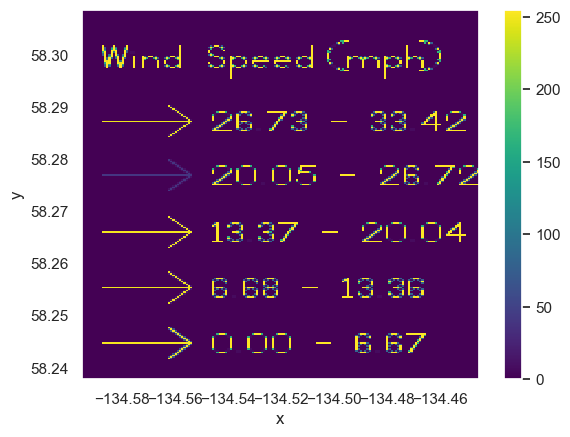

In [4]:
da.plot()

In [5]:
da

<xarray.DataArray (y: 240, x: 180)> Size: 43kB
array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(240, 180), dtype=uint8)
Coordinates:
  * x        (x) float64 1kB -134.6 -134.6 -134.6 ... -134.4 -134.4 -134.4
  * y        (y) float64 2kB 58.31 58.31 58.31 58.31 ... 58.24 58.24 58.24 58.24
Attributes:
    crs:        EPSG:4326
    transform:  (-134.5948764212, 0.0008292140377779195, 0.0, 58.3085372988, ...
    source:     /hdd/snow_hydrology/wind_ninja/test4/output/windninja_2024100...

lmao wtf is that. 

Now sure that the raster image is about, but the above code appears to have worked quite well. 

The next step is to scale this to stack all the timeseries into a netcdf datetime.

______________________________

## Scale This to Combine All the KMZs into a Time-Stacked Dataset

* Recursively searches all subfolders of your OUTPUT_DIR (one folder per run, e.g. windninja_20241001_0500)
* Extracts the timestamp from the parent folder name (pattern windninja_YYYYMMDD_HHMM)
* Finds the KMZ files inside each folder
* Converts each KMZ → xarray.DataArray (works for BMP/PNG/JPG and for both grayscale and RGB)
* Infers whether a KMZ contains wind speed or wind direction by checking the KMZ basename for common tokens (ws, speed, wd, dir, direction, spd)
* Stacks the results into a time-indexed xarray.Dataset with time, y, x dimensions
* Saves to NetCDF if desired

In [20]:
import zipfile
import tempfile
import xml.etree.ElementTree as ET
from pathlib import Path
import warnings
import numpy as np
import xarray as xr
from rasterio.transform import from_bounds
from PIL import Image
import io
import re
from datetime import datetime

# --------- Helper: convert single KMZ to xarray.DataArray ----------
def kmz_to_xarray(kmz_path):
    """
    Convert a single KMZ (contains KML + image overlay) to an xarray.DataArray.
    Returns a 2D DataArray (y, x) for grayscale images, or 3D (y, x, band) for RGB.
    CRS is EPSG:4326 (KML lat/lon).
    """
    kmz_path = Path(kmz_path)
    with zipfile.ZipFile(kmz_path, "r") as zf:
        namelist = zf.namelist()

        # find KML
        kml_candidates = [n for n in namelist if n.lower().endswith(".kml")]
        if not kml_candidates:
            raise FileNotFoundError(f"No .kml in {kmz_path}")
        kml_name = kml_candidates[0]
        kml_data = zf.read(kml_name)

        # find image (bmp/png/jpg)
        img_candidates = [n for n in namelist if n.lower().endswith((".bmp", ".png", ".jpg", ".jpeg"))]
        if not img_candidates:
            raise FileNotFoundError(f"No image (bmp/png/jpg) in {kmz_path}")
        img_name = img_candidates[0]
        img_data = zf.read(img_name)

    # Parse KML for bounding box. KML may use LatLonAltBox, LatLonBox, or GroundOverlay/LatLonQuad
    root = ET.fromstring(kml_data)
    # Namespace handling
    ns_uri = root.tag.split("}")[0].strip("{")
    ns = {"kml": ns_uri}

    # Try LatLonAltBox or LatLonBox
    # bbox_node = root.find(".//kml:LatLonAltBox", ns) or root.find(".//kml:LatLonBox", ns) # replacing this line to fix the depreciation warning from XML test
    bbox_node = root.find(".//kml:LatLonAltBox", ns)
    if bbox_node is None:
        bbox_node = root.find(".//kml:LatLonBox", ns)

    if bbox_node is not None:
        north = float(bbox_node.findtext("kml:north", namespaces=ns))
        south = float(bbox_node.findtext("kml:south", namespaces=ns))
        east = float(bbox_node.findtext("kml:east", namespaces=ns))
        west = float(bbox_node.findtext("kml:west", namespaces=ns))
    else:
        # Try LatLonQuad (often inside GroundOverlay)
        # Search without namespace for safety
        latlonquad = None
        for elem in root.iter():
            tag = elem.tag
            if tag.lower().endswith("latlonquad"):
                latlonquad = elem
                break
        if latlonquad is None:
            raise ValueError(f"No bounding box (LatLonAltBox/LatLonBox/LatLonQuad) found in {kmz_path}")
        coords_text = None
        # Look for coordinates inside latlonquad
        for ch in latlonquad:
            if ch.tag.lower().endswith("coordinates"):
                coords_text = ch.text
                break
        if coords_text is None:
            raise ValueError(f"No coordinates found inside LatLonQuad in {kmz_path}")

        coords = coords_text.strip().split()
        lonlat = [(float(c.split(",")[0]), float(c.split(",")[1])) for c in coords]
        lons, lats = zip(*lonlat)
        west, east, south, north = min(lons), max(lons), min(lats), max(lats)

    # Load image into numpy array
    with Image.open(io.BytesIO(img_data)) as img:
        # keep grayscale as 2D, color as 3D
        if img.mode in ("RGBA", "RGB"):
            img_arr = np.array(img.convert("RGBA"))  # keep alpha if present
        else:
            img_arr = np.array(img.convert("L"))

    height, width = img_arr.shape[:2]
    transform = from_bounds(west, south, east, north, width, height)

    # Create coords (x left->right, y top->bottom). y will go from north->south
    x_coords = np.linspace(west, east, width)
    y_coords = np.linspace(north, south, height)

    if img_arr.ndim == 2:
        dims = ("y", "x")
        coords = {"y": y_coords, "x": x_coords}
    else:
        dims = ("y", "x", "band")
        coords = {"y": y_coords, "x": x_coords, "band": np.arange(img_arr.shape[2])}

    da = xr.DataArray(
        img_arr,
        dims=dims,
        coords=coords,
        attrs={
            "crs": "EPSG:4326",
            "transform": transform.to_gdal(),
            "source": str(kmz_path),
        },
    )
    return da

# --------- Main: scan output dir, build time-stack dataset ----------
def build_time_stack_from_output(output_dir):
    """
    Scan ALL subfolders under output_dir. For each subfolder named like
    windninja_YYYYMMDD_HHMM, extract timestamp from the folder name and read any .kmz files inside.
    Infers variable type from kmz filename (keywords: ws, speed, spd -> wind_speed; wd, dir, direction -> wind_dir).
    Returns an xarray.Dataset with data variables wind_speed and wind_dir (if present) and time dimension.
    """
    output_dir = Path(output_dir)
    if not output_dir.exists():
        raise FileNotFoundError(output_dir)

    # containers: dict of lists keyed by variable name
    series = {"wind_speed": [], "wind_dir": []}
    times_for_var = {"wind_speed": [], "wind_dir": []}

    # Walk only immediate subdirectories (each run has its own folder), but also support nested
    for sub in sorted(output_dir.iterdir()):
        if not sub.is_dir():
            continue

        # try to extract timestamp from directory name
        m = re.search(r"windninja_(\d{8}_\d{4})", sub.name)
        if not m:
            # skip directories that don't match pattern
            print(f"Skipping directory (no timestamp pattern): {sub}")
            continue

        ts_str = m.group(1)  # e.g. 20241001_0500
        try:
            ts = datetime.strptime(ts_str, "%Y%m%d_%H%M")
        except Exception as e:
            print(f"Couldn't parse timestamp {ts_str} from {sub}: {e}")
            continue

        # find kmz files inside this run folder (non-recursive)
        kmz_files = sorted([p for p in sub.glob("*.kmz")])
        if not kmz_files:
            # maybe nested (some folders have the kmz directly inside a subfolder)
            kmz_files = sorted([p for p in sub.rglob("*.kmz")])

        if not kmz_files:
            print(f"No KMZ files in {sub} -> skipping.")
            continue

        for kmz in kmz_files:
            name = kmz.stem.lower()
            # classify variable
            if any(tok in name for tok in ("speed", "ws", "spd")):
                var = "wind_speed"
            elif any(tok in name for tok in ("dir", "wd", "direction")):
                var = "wind_dir"
            else:
                # fallback: try to guess by presence of 'speed' or 'direction' inside KML doc name
                # For now, skip if unknown (print a message)
                print(f"Unknown variable type for file {kmz.name} — skipping. (Rename to include 'ws'/'wd' etc.)")
                continue

            try:
                da = kmz_to_xarray(kmz)
            except Exception as e:
                print(f"Failed to read {kmz}: {e}")
                continue

            # Expand coords to include time dimension
            da_t = da.expand_dims(time=[np.datetime64(ts, 'ns')]) # to fix the datetime warning, cast teh nanosecond precision manually
            series[var].append(da_t)
            times_for_var[var].append(ts)

            print(f"Read {kmz.name} as {var} @ {ts_str}")

    # Concatenate series per variable
    ds = xr.Dataset()
    for var in ("wind_speed", "wind_dir"):
        if series[var]:
            try:
                concatenated = xr.concat(series[var], dim="time")
                # Sort by time (in case)
                concatenated = concatenated.sortby("time")
                ds[var] = concatenated
            except Exception as e:
                print(f"Error concatenating variable {var}: {e}. Trying to align/reshape...")
                # attempt to align by reprojecting/resampling would go here (not implemented)
        else:
            print(f"No data found for {var}")

    return ds

# ---------------- Example usage ----------------
if __name__ == "__main__":
    base_output = "/hdd/snow_hydrology/wind_ninja/test4/output"
    ds = build_time_stack_from_output(base_output)
    print(ds)
    # Save to NetCDF if desired:
    if len(ds.data_vars) > 0:
        nc_path = Path(base_output) / "windninja_time_stack.nc"
        # ds.to_netcdf(nc_path) # trying to add the three lines below to fix saving the netcdf 
        encoding = {var: {"zlib": True, "dtype": "uint8"} for var in ds.data_vars}
        encoding["time"] = {"dtype": "int64", "units": "seconds since 1970-01-01"}
        ds.to_netcdf(nc_path, format="NETCDF4", encoding=encoding)
        
        print(f"Saved stacked dataset to {nc_path}")
    else:
        print("No variables to save.")

Read dem_10m_UTM_clip_powderpatch_filled_gdal_100m.kmz as wind_dir @ 20241001_0500
Read dem_10m_UTM_clip_powderpatch_filled_gdal_100m.kmz as wind_dir @ 20241001_0600
Read dem_10m_UTM_clip_powderpatch_filled_gdal_100m.kmz as wind_dir @ 20241001_0700
Read dem_10m_UTM_clip_powderpatch_filled_gdal_100m.kmz as wind_dir @ 20241001_0800
Read dem_10m_UTM_clip_powderpatch_filled_gdal_100m.kmz as wind_dir @ 20241001_0900
Read dem_10m_UTM_clip_powderpatch_filled_gdal_100m.kmz as wind_dir @ 20241001_1000
Read dem_10m_UTM_clip_powderpatch_filled_gdal_100m.kmz as wind_dir @ 20241001_1100
Read dem_10m_UTM_clip_powderpatch_filled_gdal_100m.kmz as wind_dir @ 20241001_1200
Read dem_10m_UTM_clip_powderpatch_filled_gdal_100m.kmz as wind_dir @ 20241001_1300
Read dem_10m_UTM_clip_powderpatch_filled_gdal_100m.kmz as wind_dir @ 20241001_1400
Read dem_10m_UTM_clip_powderpatch_filled_gdal_100m.kmz as wind_dir @ 20241001_1500
Read dem_10m_UTM_clip_powderpatch_filled_gdal_100m.kmz as wind_dir @ 20241001_1600
Read

ValueError: invalid format for scipy.io.netcdf backend: 'NETCDF4'

In [21]:
ds

<xarray.Dataset> Size: 868kB
Dimensions:   (time: 20, y: 240, x: 180)
Coordinates:
  * time      (time) datetime64[ns] 160B 2024-10-01T05:00:00 ... 2024-10-02
  * y         (y) float64 2kB 58.31 58.31 58.31 58.31 ... 58.24 58.24 58.24
  * x         (x) float64 1kB -134.6 -134.6 -134.6 ... -134.4 -134.4 -134.4
Data variables:
    wind_dir  (time, y, x) uint8 864kB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0

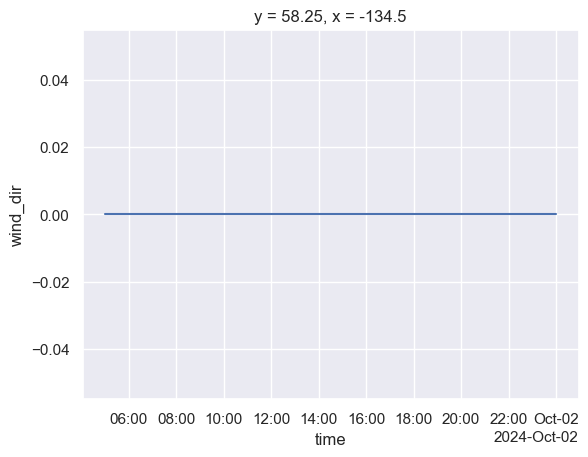

In [22]:
# select a single gridcell of ds 
# select one y and one x index
ds.wind_dir.isel(y=200, x=100).plot()

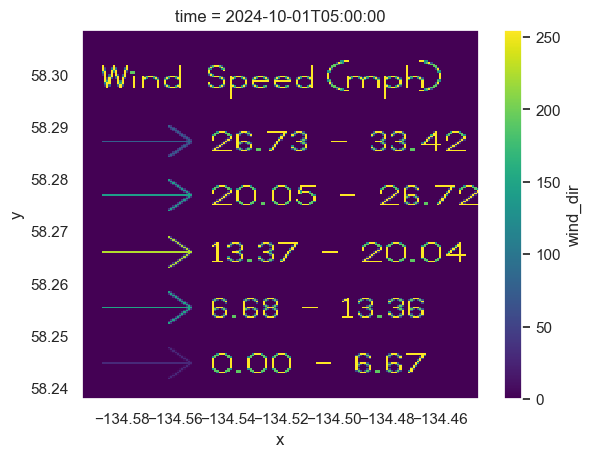

In [23]:
ds.wind_dir.isel(time=0).plot()

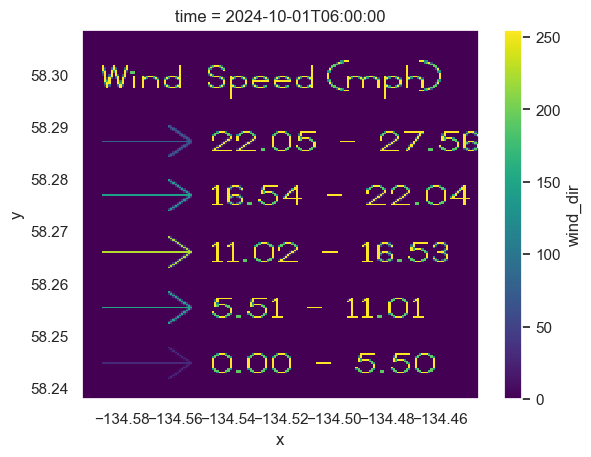

In [24]:
ds.wind_dir.isel(time=1).plot()

it looks like wind speed and direction are contained together...

(array([8.10774e+05, 6.37900e+03, 9.36700e+03, 7.72000e+02, 0.00000e+00,
        6.39000e+03, 2.39000e+02, 6.75600e+03, 1.22000e+03, 2.21030e+04]),
 array([  0. ,  25.5,  51. ,  76.5, 102. , 127.5, 153. , 178.5, 204. ,
        229.5, 255. ]),
 <BarContainer object of 10 artists>)

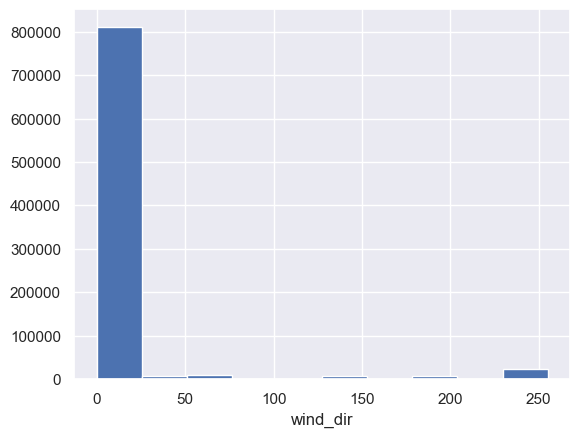

In [25]:
ds.wind_dir.plot()

maybe I will need other methods to read the KMZ files and work with them in python...

# Trying New Things Today: 29 Oct 2025

### Let's try fixing the above code...
1. The KMZ contains a colorized image, not numeric wind data.
* The “Wind Speed (mph)” legend drawn directly on the image shows that this is a rendered visualization, not a numeric raster of m/s or mph values.
* Each color corresponds to a range of speeds — WindNinja produces a KML overlay for Google Earth, not a quantitative grid.

    Which is why, 
    * wind_speed wasn’t found as a separate file (only one image per .kmz),

    * The uint8 values you see are just pixel color intensities (not actual speeds),
    * And the plot shows arrows and text, not a field.

2. The “DeprecationWarning” messages are minor and easy to silence — they come from truth-testing an XML node directly and from np.datetime64 precision handling in xarray.

3. The NetCDF save error happens because uint8 + default NetCDF3 encoding + nanosecond datetimes → type mismatch. We’ll fix that by forcing NetCDF4 and specifying encodings.

### We fix it by, 
We’ll make three improvements:

Parse KMZ safely (silence warnings, clean XML handling).

Force NetCDF4 and set encoding to handle uint8 and datetimes cleanly.

Flag these images clearly as visual layers, not numeric wind speed.
(Later, I can help you extract numeric values from WindNinja outputs instead of these .kmz renderings — they can be generated as .asc or .tif if you enable that mode.)


## The Real Problem is the Data...
-------

But: your current .kmz is not real data

The file is a Google Earth overlay — each pixel encodes color, not wind speed.
You can tell because:

It includes the legend and arrows inside the image itself.

WindNinja uses KML overlays for visualization, and numeric outputs come as .asc or .tif.